In [64]:
import pandas as pd
# Check the data
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

#View the data 
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())



   VIN (1-10)    County               City State  Postal Code  Model Year  \
0  1N4AZ0CP6D      King           Kirkland    WA      98034.0        2013   
1  5YJ3E1EC8L    Kitsap  Bainbridge Island    WA      98110.0        2020   
2  5YJ3E1EBXJ      King            Seattle    WA      98144.0        2018   
3  ZFAFFAC45R  Thurston               Yelm    WA      98597.0        2024   
4  5YJYGDEE3L      King               Kent    WA      98030.0        2020   

     Make    Model           Electric Vehicle Type  \
0  NISSAN     LEAF  Battery Electric Vehicle (BEV)   
1   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
2   TESLA  MODEL 3  Battery Electric Vehicle (BEV)   
3    FIAT     500E  Battery Electric Vehicle (BEV)   
4   TESLA  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible            75.0   
1            Clean Alternative Fuel Vehicle Eligible           308.0

In [65]:
# keep useful columns only if they exist
cleaned_df = df[[
    'County',
    'City',
    'State',
    'Model Year',
    'Make',
    'Model',
    'Electric Vehicle Type',
    'Electric Range'
]]

# remove duplicates/NA and cleans the data
cleaned_df = cleaned_df.drop_duplicates()
cleaned_df = cleaned_df.dropna()
cleaned_df[['Make','Model','County','City','Electric Vehicle Type']] = cleaned_df[['Make','Model','County','City','Electric Vehicle Type']].apply(lambda x: x.str.strip().str.title())
df["Model Year"] = pd.to_numeric(df["Model Year"])
df["Electric Range"] = pd.to_numeric(df["Electric Range"])
cleaned_df




,County,City,State,Model Year,Make,Model,Electric Vehicle Type,Electric Range
0,King,Kirkland,WA,2013,Nissan,Leaf,Battery Electric Vehicle (Bev),75.0
1,Kitsap,Bainbridge Island,WA,2020,Tesla,Model 3,Battery Electric Vehicle (Bev),308.0
2,King,Seattle,WA,2018,Tesla,Model 3,Battery Electric Vehicle (Bev),215.0
3,Thurston,Yelm,WA,2024,Fiat,500E,Battery Electric Vehicle (Bev),0.0
4,King,Kent,WA,2020,Tesla,Model Y,Battery Electric Vehicle (Bev),291.0
...,...,...,...,...,...,...,...,...
280800,Manassas,Manassas,VA,2021,Audi,Q5 E,Plug-In Hybrid Electric Vehicle (Phev),18.0
280801,Kitsap,Port Gamble,WA,2018,Chrysler,Pacifica,Plug-In Hybrid Electric Vehicle (Phev),33.0
280815,Snohomish,Mill Creek,WA,2020,Bmw,X3,Plug-In Hybrid Electric Vehicle (Phev),17.0
280825,Whatcom,Custer,WA,2023,Chevrolet,Bolt Ev,Battery Electric Vehicle (Bev),0.0


In [87]:
# Which counties have the highest EV counts?
county_counts = cleaned_df["County"].value_counts().head(10)
print(county_counts)

County
King         12463
Pierce        5677
Snohomish     5420
Kitsap        2396
Clark         2392
Spokane       2009
Thurston      1615
Whatcom       1579
Island        1329
Skagit        1215
Name: count, dtype: int64


In [88]:
#2. Which EV manufacturers are most popular?
make_counts = cleaned_df["Make"].value_counts().head(10)
print(make_counts)

Make
Tesla        8295
Chevrolet    3851
Ford         3548
Bmw          3481
Kia          3336
Toyota       2823
Nissan       2618
Volvo        2363
Hyundai      2347
Audi         1940
Name: count, dtype: int64


In [68]:
#4. What types of EVs are most common?
type_counts = df["Electric Vehicle Type"].value_counts()
print(type_counts)

Electric Vehicle Type
Battery Electric Vehicle (BEV)            225124
Plug-in Hybrid Electric Vehicle (PHEV)     55709
Name: count, dtype: int64


In [89]:
#5. Which models appear most often?
model_counts = cleaned_df["Model"].value_counts().head(10)
print(model_counts)

Model
Model 3               2503
Leaf                  2201
Model Y               2097
Model S               1880
Model X               1405
Bolt Ev               1213
Niro                  1197
Volt                  1136
Prius Prime (Phev)    1097
Wrangler               970
Name: count, dtype: int64


In [70]:
#6. What is the average electric range by manufacturer?
avg_range = df.groupby("Make")["Electric Range"].mean().sort_values(ascending=False).head(10)
print(avg_range)

Make
JAGUAR                  167.802632
WHEEGO ELECTRIC CARS    100.000000
TH!NK                   100.000000
CHEVROLET                76.944513
FIAT                     73.831169
NISSAN                   63.327741
SMART                    61.652174
AZURE DYNAMICS           56.000000
TESLA                    50.871151
LAND ROVER               50.685590
Name: Electric Range, dtype: float64


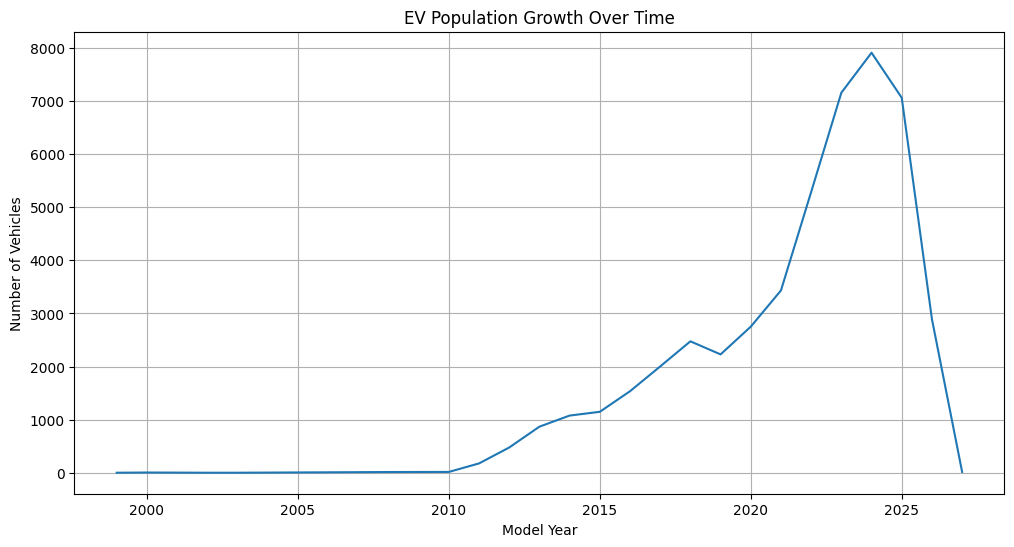

In [90]:
#1. EV population growth over time
import matplotlib.pyplot as plt
year_counts = cleaned_df["Model Year"].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values)
plt.title("EV Population Growth Over Time") 
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.grid(True)
plt.show()


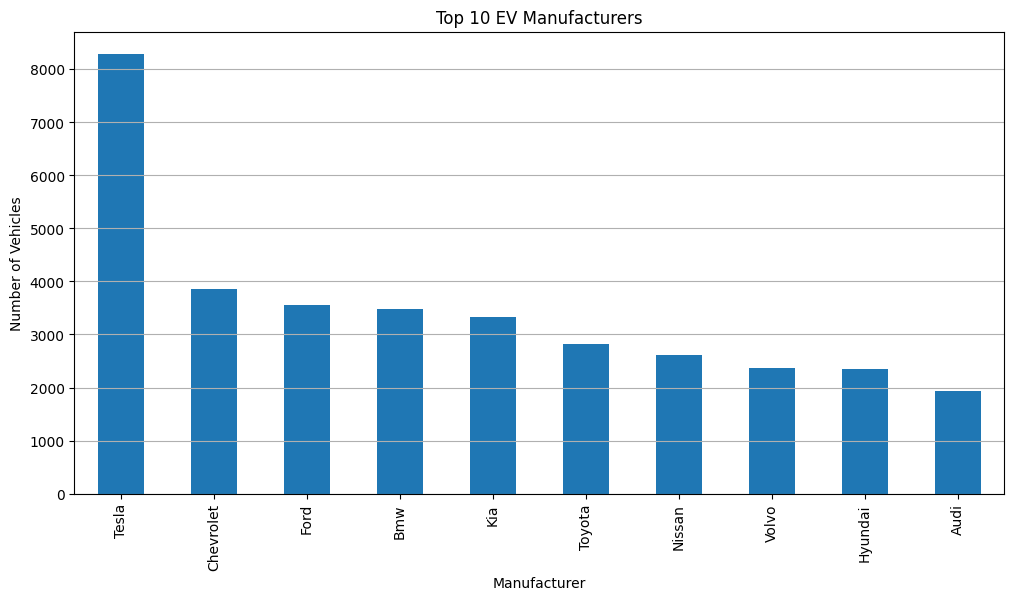

In [92]:
import matplotlib.pyplot as plt

make_counts = cleaned_df["Make"].value_counts().head(10)

plt.figure(figsize=(12,6))
make_counts.plot(kind="bar")

plt.title("Top 10 EV Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Vehicles")
plt.grid(axis='y')
plt.show()

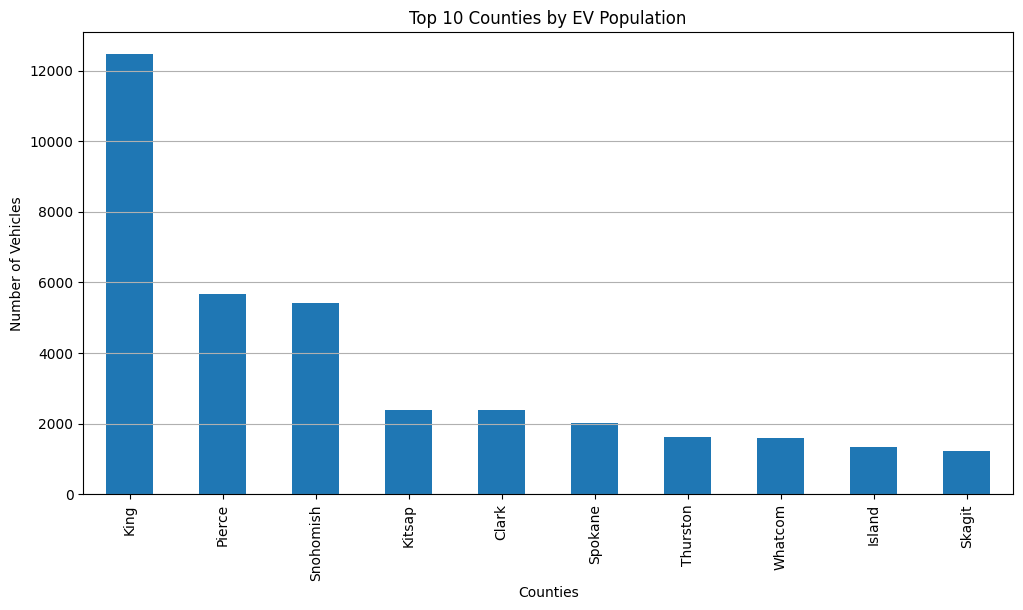

In [93]:
import matplotlib.pyplot as plt

county_counts = cleaned_df["County"].value_counts().head(10)
plt.figure(figsize=(12,6))
county_counts.plot(kind="bar")

plt.title("Top 10 Counties by EV Population")
plt.xlabel("Counties")
plt.ylabel("Number of Vehicles")
plt.grid(axis='y')
plt.show()

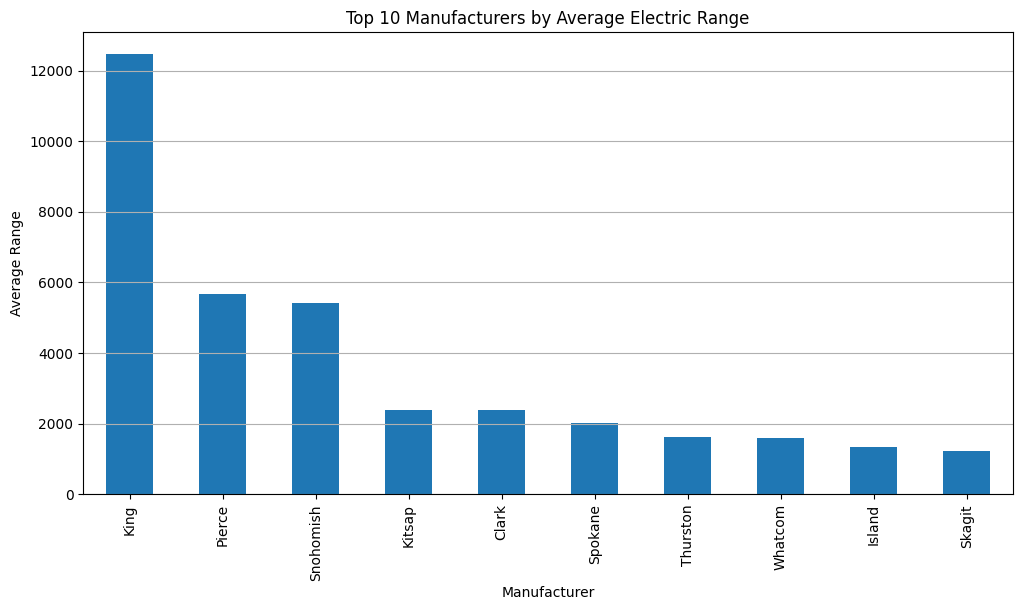

In [96]:
import matplotlib.pyplot as plt

avg_range = df.groupby("Make")["Electric Range"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
county_counts.plot(kind="bar")

plt.title("Top 10 Manufacturers by Average Electric Range")
plt.xlabel("Manufacturer")
plt.ylabel("Average Range")
plt.grid(axis='y')
plt.show()